In [1]:
# Importar las librerías necesarias
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


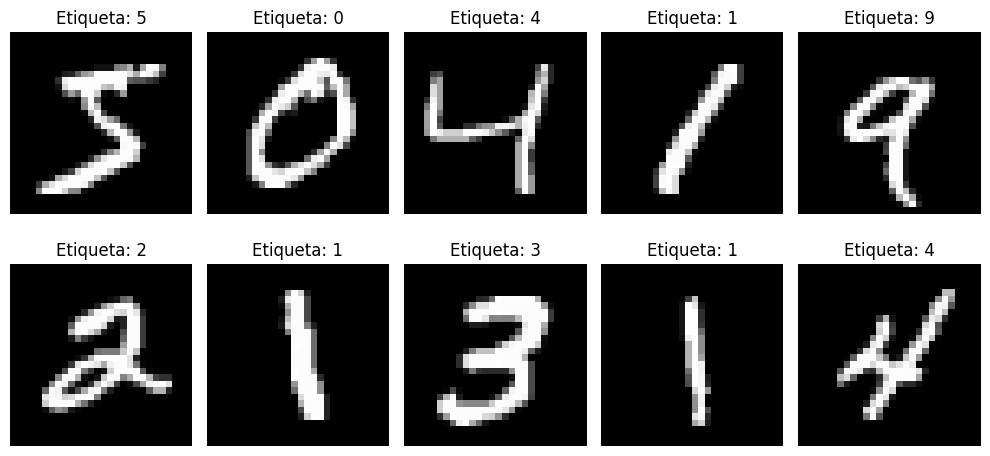

Forma de x_train: (60000, 28, 28), y_train: (60000,)
Forma de x_test: (10000, 28, 28), y_test: (10000,)


In [2]:
# Cargar el dataset MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalizar los datos a un rango de [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# Mostrar ejemplos del dataset
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Etiqueta: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Forma de x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"Forma de x_test: {x_test.shape}, y_test: {y_test.shape}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

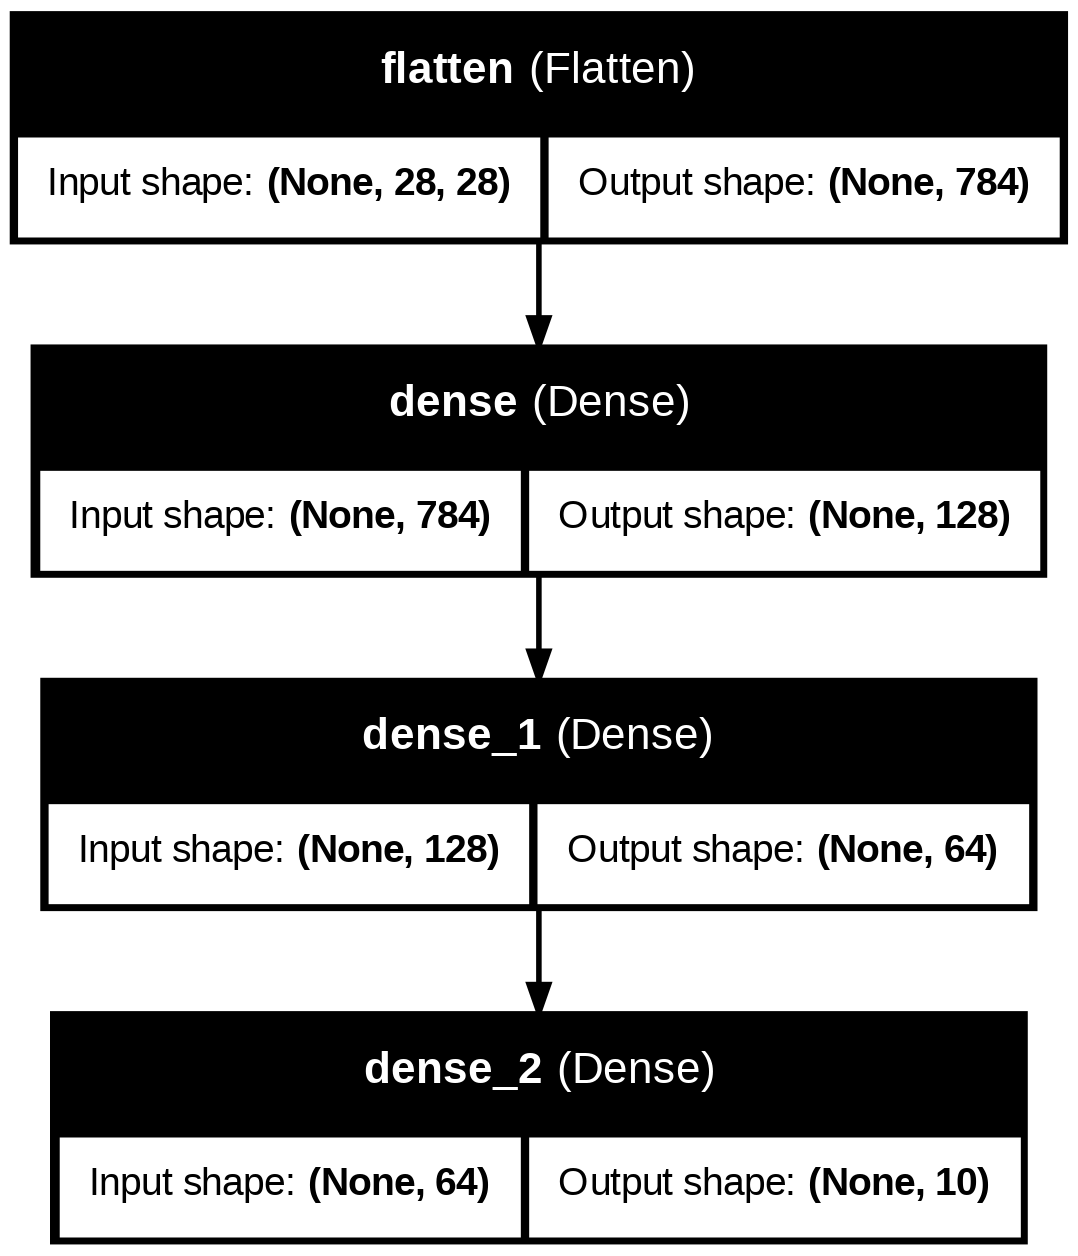

In [3]:
# Crear el modelo secuencial
model = Sequential([
    Flatten(input_shape=(28, 28)),       # Aplanar las imágenes 28x28
    Dense(128, activation='relu'),       # Capa densa con 128 neuronas y activación ReLU
    Dense(64, activation='relu'),        # Capa densa con 64 neuronas y activación ReLU
    Dense(10, activation='softmax')      # Capa de salida con 10 neuronas (una por clase)
])

# Compilar el modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen del modelo
model.summary()

# Visualizar la arquitectura del modelo
plot_model(model, show_shapes=True, show_layer_names=True)


In [4]:
# Entrenar el modelo
history = model.fit(
    x_train, y_train,
    validation_split=0.2,       # Usar el 20% del conjunto de entrenamiento para validación
    epochs=10,                  # Número de épocas
    batch_size=32,              # Tamaño del lote
    verbose=1                   # Mostrar progreso
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8621 - loss: 0.4660 - val_accuracy: 0.9586 - val_loss: 0.1428
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9629 - loss: 0.1239 - val_accuracy: 0.9631 - val_loss: 0.1255
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9754 - loss: 0.0778 - val_accuracy: 0.9711 - val_loss: 0.0949
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9842 - loss: 0.0535 - val_accuracy: 0.9707 - val_loss: 0.1014
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9859 - loss: 0.0440 - val_accuracy: 0.9731 - val_loss: 0.0955
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9892 - loss: 0.0341 - val_accuracy: 0.9720 - val_loss: 0.1040
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9908 - loss: 0.0272 - val_accuracy: 0.9687 - val_loss: 0.1320
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9920 - loss: 0.02

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9711 - loss: 0.1127
Precisión en el conjunto de prueba: 97.48%


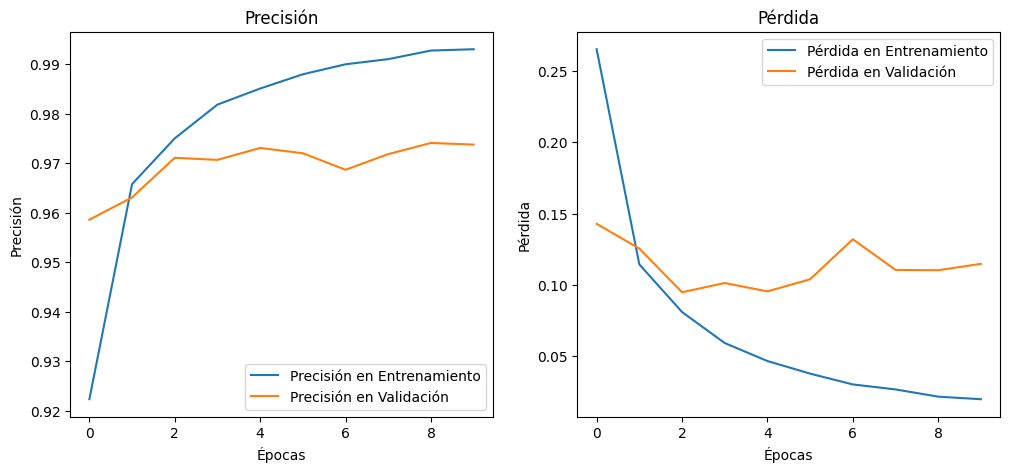

In [5]:
# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print(f"Precisión en el conjunto de prueba: {test_accuracy * 100:.2f}%")

# Graficar la precisión y pérdida durante el entrenamiento
plt.figure(figsize=(12, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión en Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión en Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida en Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida en Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


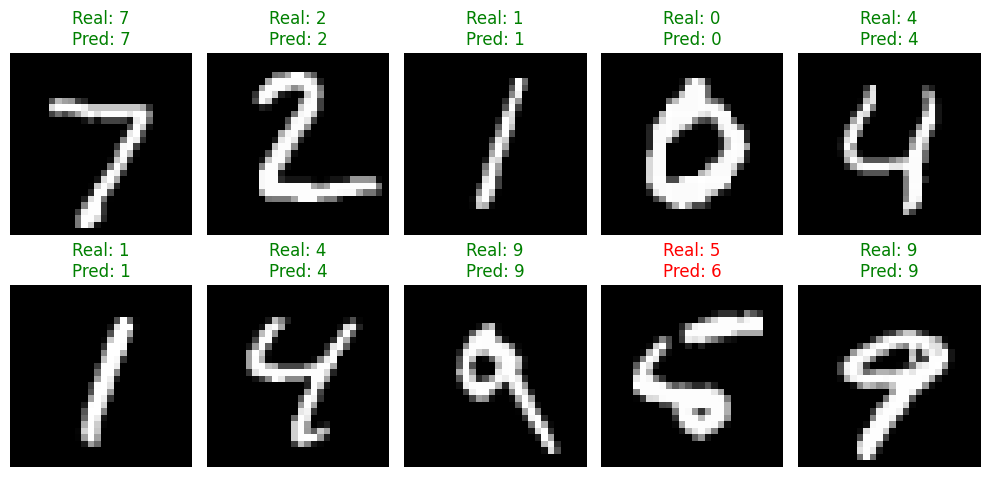

In [6]:
# Hacer predicciones
predictions = model.predict(x_test)

# Mostrar algunos ejemplos con predicciones
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    predicted_label = tf.argmax(predictions[i]).numpy()
    true_label = y_test[i]
    color = 'green' if predicted_label == true_label else 'red'
    plt.title(f"Real: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()
